# 02 Baseline U-Net

This notebook implements the baseline U-Net model using the processed STRUM RGB dataset.

Input:
- RGB Sentinel-2 images
- Shape: (3,128,128)

Output:
- Binary flood segmentation mask
- Shape: (1,128,128)

The baseline model will be used for comparison against the Hybrid SAM-U-Net architecture.

In [64]:
import os
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [65]:
import sys
import torch

print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

c:\Users\KRITHI S KULAL\Desktop\TECH\UNET+HYBRID_MODEL\venv\Scripts\python.exe
2.12.0+cu126
12.6
True


In [66]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 2050


In [67]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

IMAGE_SIZE = 128

BATCH_SIZE = 8

LEARNING_RATE = 1e-4

EPOCHS = 80

Device: cuda


In [68]:
PROCESSED_PATH = Path(
    "../dataset/processed/STRUM"
)

TRAIN_IMAGE_DIR = (
    PROCESSED_PATH /
    "train" /
    "images"
)

TRAIN_MASK_DIR = (
    PROCESSED_PATH /
    "train" /
    "masks"
)

VAL_IMAGE_DIR = (
    PROCESSED_PATH /
    "val" /
    "images"
)

VAL_MASK_DIR = (
    PROCESSED_PATH /
    "val" /
    "masks"
)

TEST_IMAGE_DIR = (
    PROCESSED_PATH /
    "test" /
    "images"
)

TEST_MASK_DIR = (
    PROCESSED_PATH /
    "test" /
    "masks"
)

In [69]:
train_images = sorted(
    list(TRAIN_IMAGE_DIR.glob("*.npy"))
)

train_masks = sorted(
    list(TRAIN_MASK_DIR.glob("*.npy"))
)

print("Train Images:", len(train_images))
print("Train Masks :", len(train_masks))

Train Images: 2140
Train Masks : 2140


In [70]:
sample_image = np.load(
    train_images[0]
)

sample_mask = np.load(
    train_masks[0]
)

print("Image Shape :", sample_image.shape)
print("Mask Shape  :", sample_mask.shape)

print("Image Min   :", sample_image.min())
print("Image Max   :", sample_image.max())

print("Mask Classes:", np.unique(sample_mask))

Image Shape : (3, 128, 128)
Mask Shape  : (128, 128)
Image Min   : 0.0
Image Max   : 1.0
Mask Classes: [0 1]


In [71]:
print(
    "Image Has NaN:",
    np.isnan(sample_image).any()
)

print(
    "Image Has Inf:",
    np.isinf(sample_image).any()
)

print(
    "Mask Has NaN:",
    np.isnan(sample_mask).any()
)

Image Has NaN: False
Image Has Inf: False
Mask Has NaN: False


In [72]:
bad_images = 0

for file in train_images:

    image = np.load(file)

    if np.isnan(image).any():

        bad_images += 1

print(
    "Images Containing NaN:",
    bad_images
)

Images Containing NaN: 0


In [52]:
sample_image.shape
sample_mask.shape

sample_image.min()
sample_image.max()

np.unique(sample_mask)

array([0, 1], dtype=uint8)

In [76]:
bad_files = []

for file in train_images:

    image = np.load(file)

    if np.isnan(image).any():

        bad_files.append(file)

print("Bad Files Found:", len(bad_files))

for f in bad_files:
    print(f)

Bad Files Found: 0


In [121]:
x = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    y = model(x)

print(y.shape)

torch.Size([1, 1, 128, 128])


In [122]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {total_params:,}"
)

Parameters: 31,037,633


## Dataset Class

Loads processed RGB images and binary masks from the processed STRUM dataset.

In [145]:
import random
from pathlib import Path
from torch.utils.data import Dataset
import numpy as np
import torch


class FloodDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        augment=False
    ):

        self.images = sorted(
            list(Path(image_dir).glob("*.npy"))
        )

        self.masks = sorted(
            list(Path(mask_dir).glob("*.npy"))
        )

        self.augment = augment

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        # Load image
        image = np.load(
            self.images[idx]
        )

        # Load mask
        mask = np.load(
            self.masks[idx]
        )

        # =====================
        # Data Augmentation
        # =====================

        if self.augment:

            # Horizontal Flip
            if random.random() > 0.5:

                image = np.flip(
                    image,
                    axis=2
                ).copy()

                mask = np.flip(
                    mask,
                    axis=1
                ).copy()

            # Vertical Flip
            if random.random() > 0.5:

                image = np.flip(
                    image,
                    axis=1
                ).copy()

                mask = np.flip(
                    mask,
                    axis=0
                ).copy()

            # Random 90° Rotation
            k = random.randint(0, 3)

            image = np.rot90(
                image,
                k,
                axes=(1, 2)
            ).copy()

            mask = np.rot90(
                mask,
                k
            ).copy()

        # Add channel dimension
        mask = np.expand_dims(
            mask,
            axis=0
        )

        # Convert to tensor
        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        return image, mask

In [146]:
train_dataset = FloodDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR,
    augment=True
)

val_dataset = FloodDataset(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR,
    augment=False
)

test_dataset = FloodDataset(
    TEST_IMAGE_DIR,
    TEST_MASK_DIR,
    augment=False
)

In [147]:
mask_files = list(
    Path(TRAIN_MASK_DIR).glob("*.npy")
)

water_pixels = 0
background_pixels = 0

for mask_file in mask_files:

    mask = np.load(mask_file)

    water_pixels += np.sum(mask == 1)
    background_pixels += np.sum(mask == 0)

pos_weight = background_pixels / water_pixels

print("Background:", background_pixels)
print("Water:", water_pixels)
print("Pos Weight:", pos_weight)

Background: 25243294
Water: 9818466
Pos Weight: 2.5710018245212645


In [88]:
image, mask = train_dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape :", mask.shape)

print("Image Min :", image.min())
print("Image Max :", image.max())

print("Mask Classes:")
print(torch.unique(mask))

Image Shape: torch.Size([3, 128, 128])
Mask Shape : torch.Size([1, 128, 128])
Image Min : tensor(0.)
Image Max : tensor(1.)
Mask Classes:
tensor([0., 1.])


In [125]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

print(torch.unique(masks))

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])
tensor([0., 1.])


## U-Net Architecture

Baseline U-Net for binary flood segmentation.

Input:
- RGB Image (3×128×128)

Output:
- Binary Flood Mask (1×128×128)

In [148]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [149]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):

        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Encoder

        self.down1 = DoubleConv(
            in_channels,
            64
        )

        self.down2 = DoubleConv(
            64,
            128
        )

        self.down3 = DoubleConv(
            128,
            256
        )

        self.down4 = DoubleConv(
            256,
            512
        )

        # Bottleneck

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Decoder

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        d1 = self.down1(x)

        d2 = self.down2(
            self.pool(d1)
        )

        d3 = self.down3(
            self.pool(d2)
        )

        d4 = self.down4(
            self.pool(d3)
        )

        bottleneck = self.bottleneck(
            self.pool(d4)
        )

        u4 = self.up4(
            bottleneck
        )

        u4 = torch.cat(
            [u4, d4],
            dim=1
        )

        u4 = self.dec4(u4)

        u3 = self.up3(u4)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.dec3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.dec2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.dec1(u1)

        return self.final(u1)

In [150]:
model = UNet().to(DEVICE)

print(model)

UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.

In [151]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print(outputs.shape)

print(
    outputs.min()
)

print(
    outputs.max()
)

print(
    torch.isnan(outputs).any()
)

torch.Size([8, 1, 128, 128])
tensor(-1.9222, device='cuda:0')
tensor(2.5952, device='cuda:0')
tensor(False, device='cuda:0')


In [152]:
import torch.nn as nn
import torch


class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):

        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (
            probs * targets
        ).sum()

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            probs.sum()
            + targets.sum()
            + self.smooth
        )

        return 1 - dice


class WeightedBCEDiceLoss(nn.Module):

    def __init__(
        self,
        pos_weight
    ):

        super().__init__()

        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(
                [pos_weight],
                dtype=torch.float32
            ).to(DEVICE)
        )

        self.dice = DiceLoss()

    def forward(
        self,
        logits,
        targets
    ):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        return (
            bce_loss
            + dice_loss
        )

In [154]:
criterion = WeightedBCEDiceLoss(
    pos_weight=pos_weight
)

In [155]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [156]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [157]:
train_losses = []
val_losses = []

train_ious = []
val_ious = []

train_accs = []
val_accs = []

best_val_iou = 0.0

In [158]:
CHECKPOINT_PATH = (
    "../checkpoints/best_unet_weighted_augmented.pth"
)

In [160]:
def compute_iou(
    logits,
    targets,
    threshold=0.5
):

    probs = torch.sigmoid(logits)

    preds = (
        probs > threshold
    ).float()

    intersection = (
        preds * targets
    ).sum()

    union = (
        preds + targets
    ).sum() - intersection

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return iou.item()

In [161]:
def compute_accuracy(
    logits,
    targets,
    threshold=0.5
):

    probs = torch.sigmoid(logits)

    preds = (
        probs > threshold
    ).float()

    correct = (
        preds == targets
    ).float()

    accuracy = correct.mean()

    return accuracy.item()

In [162]:
from tqdm import tqdm

In [163]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    epoch_loss = 0.0
    epoch_iou = 0.0
    epoch_acc = 0.0

    for images, masks in tqdm(loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        epoch_iou += compute_iou(
            outputs.detach(),
            masks
        )

        epoch_acc += compute_accuracy(
            outputs.detach(),
            masks
        )

    epoch_loss /= len(loader)
    epoch_iou /= len(loader)
    epoch_acc /= len(loader)

    return (
        epoch_loss,
        epoch_iou,
        epoch_acc
    )

In [164]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    epoch_loss = 0.0
    epoch_iou = 0.0
    epoch_acc = 0.0

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            epoch_loss += loss.item()

            epoch_iou += compute_iou(
                outputs,
                masks
            )

            epoch_acc += compute_accuracy(
                outputs,
                masks
            )

    epoch_loss /= len(loader)
    epoch_iou /= len(loader)
    epoch_acc /= len(loader)

    return (
        epoch_loss,
        epoch_iou,
        epoch_acc
    )

In [165]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

outputs = model(images)

loss = criterion(
    outputs,
    masks
)

print(outputs.shape)

print(loss.item())

print(torch.isnan(loss))

torch.Size([8, 1, 128, 128])
1.0489351749420166
tensor(False, device='cuda:0')


In [166]:
EPOCHS = 100

for epoch in range(EPOCHS):

    train_loss, train_iou, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss, val_iou, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_ious.append(train_iou)
    val_ious.append(val_iou)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_iou > best_val_iou:

        best_val_iou = val_iou

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val IoU={val_iou:.4f} | "
        f"LR={current_lr:.6f}"
    )

  0%|          | 0/268 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:09<00:00,  3.45it/s]


Epoch [001/100] | Train Loss=1.2372 | Val Loss=1.1767 | Val IoU=0.4452 | LR=0.000100


100%|██████████| 34/34 [00:02<00:00, 12.88it/s]


Epoch [002/100] | Train Loss=1.2189 | Val Loss=1.1920 | Val IoU=0.4426 | LR=0.000100


...

Epoch [098/100] | Train Loss=0.4994 | Val Loss=0.8999 | Val IoU=0.5588 | LR=0.000000


100%|██████████| 34/34 [00:02<00:00, 12.77it/s]


Epoch [099/100] | Train Loss=0.5005 | Val Loss=0.8910 | Val IoU=0.5681 | LR=0.000000


100%|██████████| 34/34 [00:02<00:00, 12.87it/s]

Epoch [100/100] | Train Loss=0.4930 | Val Loss=0.9079 | Val IoU=0.5586 | LR=0.000000


In [167]:
print(
    f"Best Validation IoU: {best_val_iou:.4f}"
)

Best Validation IoU: 0.5681


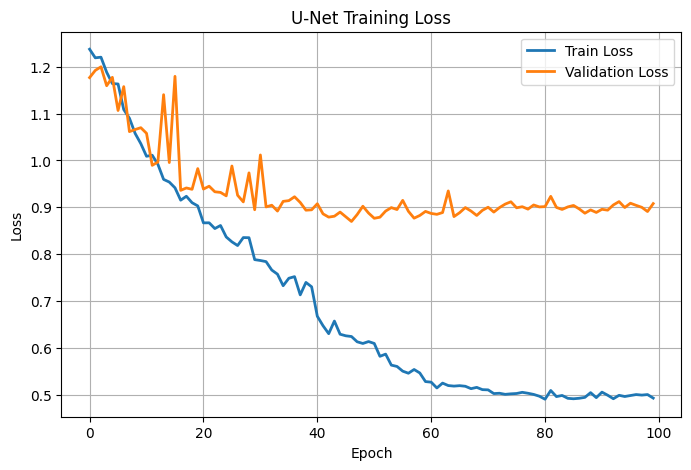

In [168]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("U-Net Training Loss")

plt.legend()

plt.grid(True)

plt.show()

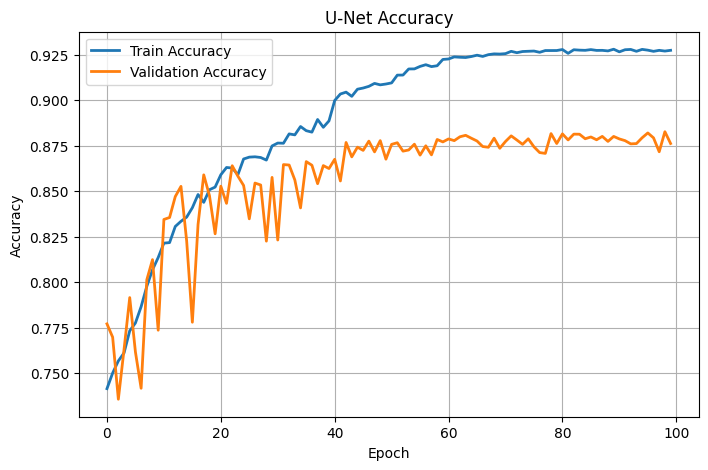

In [171]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    val_accs,
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("U-Net Accuracy")

plt.legend()

plt.grid(True)

plt.show()

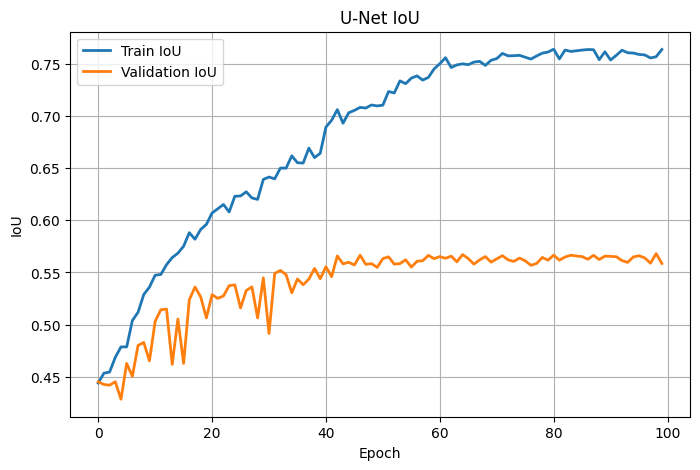

In [172]:
plt.figure(figsize=(8,5))

plt.plot(
    train_ious,
    label="Train IoU",
    linewidth=2
)

plt.plot(
    val_ious,
    label="Validation IoU",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.title("U-Net IoU")

plt.legend()

plt.grid(True)

plt.show()

In [173]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

In [176]:
model = UNet().to(DEVICE)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [174]:
def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            outputs = model(images)

            preds = (
                torch.sigmoid(outputs) > 0.5
            ).float()

            all_preds.extend(
                preds.cpu().numpy().flatten()
            )

            all_targets.extend(
                masks.numpy().flatten()
            )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    iou = jaccard_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    dice = (
        2 * precision * recall
    ) / (
        precision + recall + 1e-8
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Dice Score": dice,
        "IoU": iou
    }

In [175]:
results = evaluate_model(
    model,
    test_loader,
    DEVICE
)

for metric, value in results.items():

    print(
        f"{metric}: {value:.4f}"
    )

Accuracy: 0.8984
Precision: 0.7823
Recall: 0.8269
F1 Score: 0.8040
Dice Score: 0.8040
IoU: 0.6722


In [177]:
metrics_df = pd.DataFrame(
    {
        "Metric": results.keys(),
        "Value": results.values()
    }
)

metrics_df

,Metric,Value
0,Accuracy,0.898391
1,Precision,0.782343
2,Recall,0.826857
3,F1 Score,0.803984
4,Dice Score,0.803984
5,IoU,0.672219


In [178]:
def visualize_predictions(
    model,
    dataset,
    device,
    num_samples=5
):

    model.eval()

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(12, 4*num_samples)
    )

    with torch.no_grad():

        for i in range(num_samples):

            image, mask = dataset[i]

            prediction = model(
                image.unsqueeze(0).to(device)
            )

            prediction = (
                torch.sigmoid(prediction)
                > 0.5
            ).float()

            rgb = image.permute(
                1,
                2,
                0
            ).numpy()

            axes[i,0].imshow(rgb)
            axes[i,0].set_title("RGB Image")
            axes[i,0].axis("off")

            axes[i,1].imshow(
                mask.squeeze(),
                cmap="Blues"
            )
            axes[i,1].set_title("Ground Truth")
            axes[i,1].axis("off")

            axes[i,2].imshow(
                prediction.squeeze().cpu(),
                cmap="Blues"
            )
            axes[i,2].set_title("Prediction")
            axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

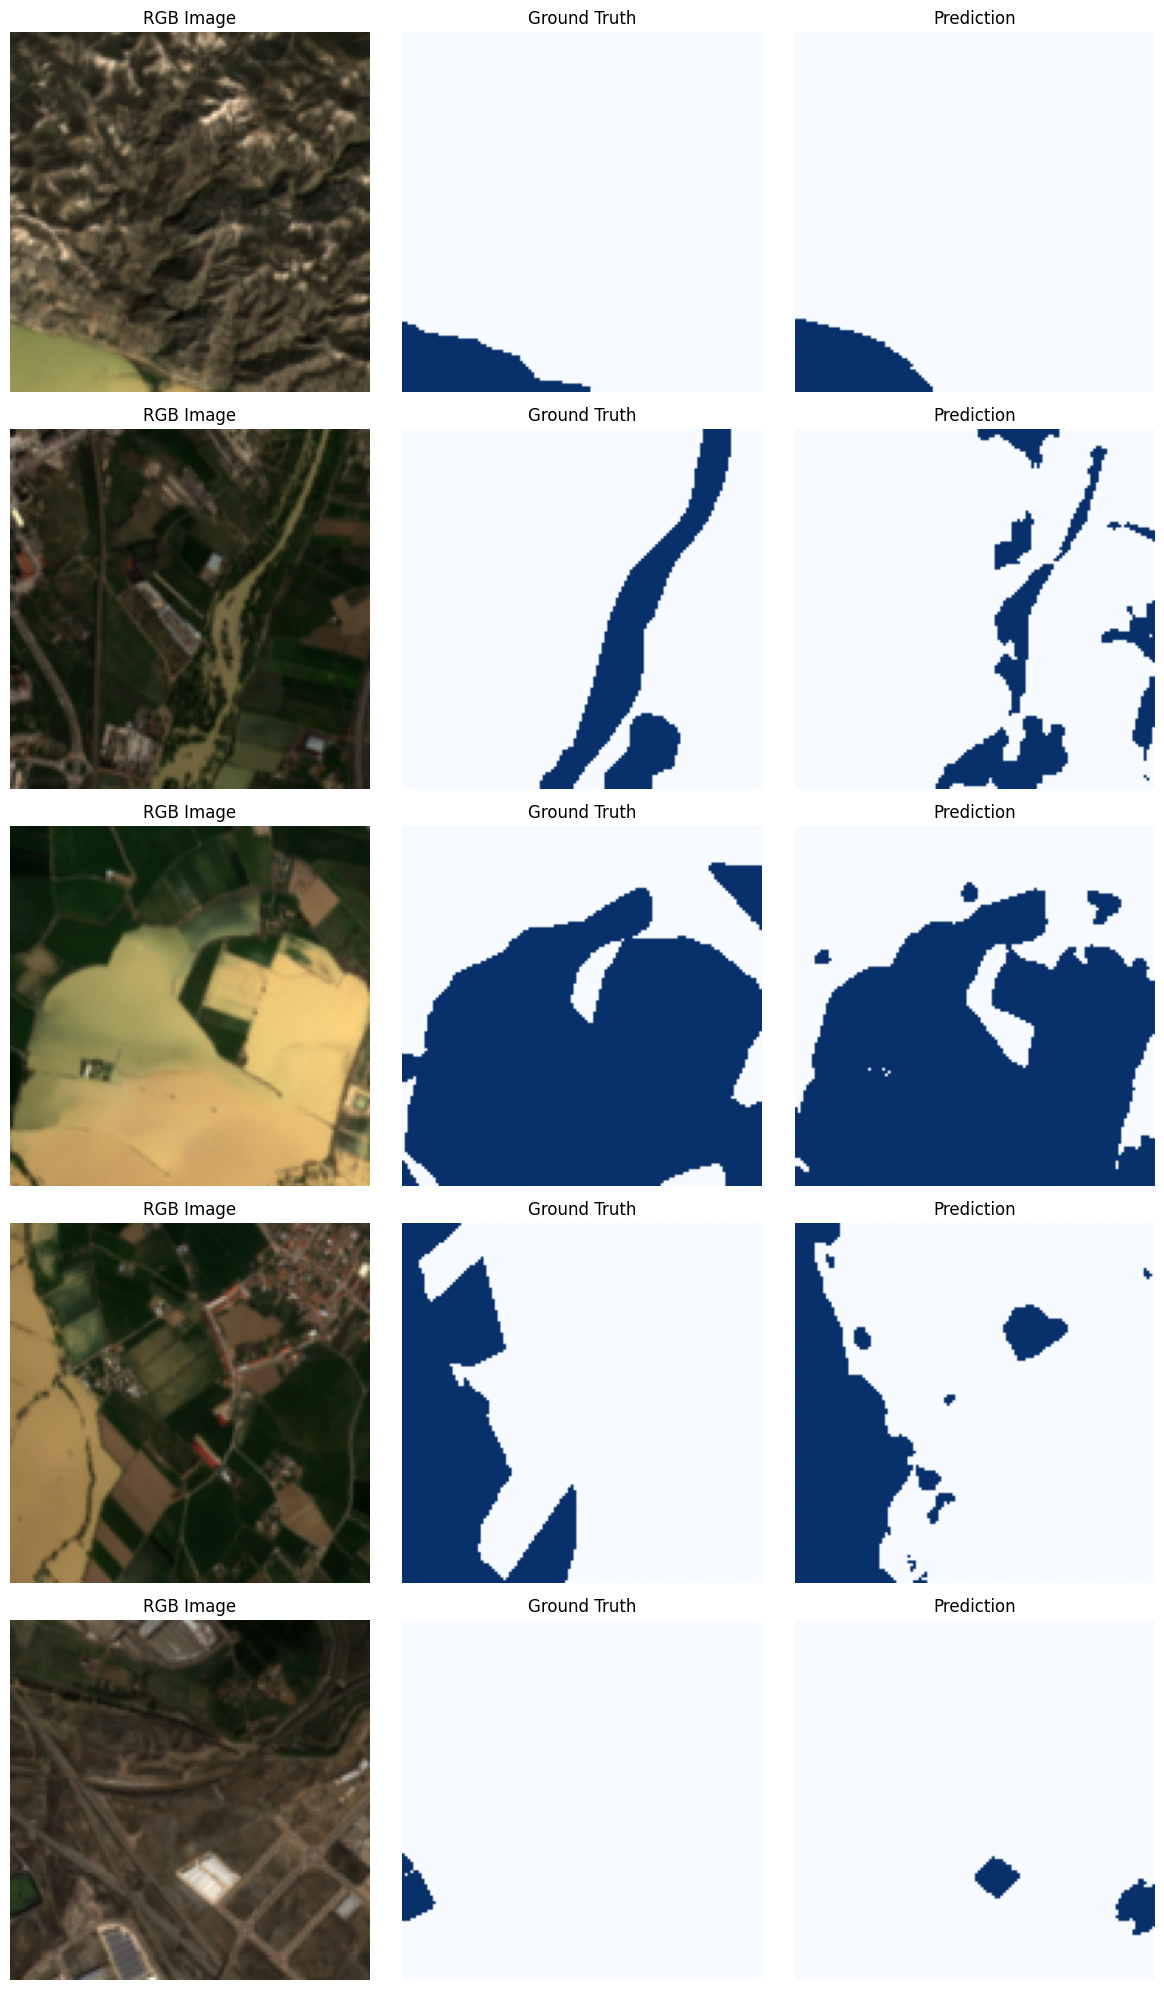

In [179]:
visualize_predictions(
    model,
    test_dataset,
    DEVICE,
    num_samples=5
)